In [ ]:
#STEP 1 — Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In this step, the required Python libraries are imported for performing the clinical cancer classification analysis. Pandas is used to load, organize, and manipulate the clinical dataset. Matplotlib is used to create the graphical representation of the confusion matrix. Scikit-learn provides the functions required for splitting the dataset, selecting important features, training the Random Forest classification model, making predictions, and evaluating the model's performance.

In [ ]:
#STEP 2 — Upload and Load the Dataset
uploaded = files.upload()

filename = list(uploaded.keys())[0]

raw_data = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", raw_data.shape)

display(raw_data.head())

Saving dataset_lungcancer.csv to dataset_lungcancer.csv
Dataset loaded successfully!
Dataset shape: (3000, 16)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


In this step, the clinical lung cancer dataset is uploaded to Google Colab and loaded into a Pandas DataFrame. A DataFrame is a tabular structure that allows the clinical information to be easily analyzed and processed using Python. The shape of the dataset is displayed to identify the number of samples and variables, and the first five rows are displayed to understand the structure and contents of the dataset.

In [ ]:
#STEP 3 — Check the Target Variable
print("LUNG_CANCER values:")
print(raw_data["LUNG_CANCER"].value_counts())

LUNG_CANCER values:
LUNG_CANCER
YES    1518
NO     1482
Name: count, dtype: int64


In this step, the target variable LUNG_CANCER is examined to identify the different outcome classes present in the dataset. The target variable represents whether an individual belongs to the cancer or non-cancer group. In this dataset, YES represents the cancer or disease group, while NO represents the non-cancer or non-disease group. Checking the target values before preprocessing helps confirm that the classification outcome is correctly defined.

In [ ]:
#STEP 4 — Data Preprocessing
#Make a copy of the original dataset
data = raw_data.copy()

# Remove duplicate records
data = data.drop_duplicates().reset_index(drop=True)

# Convert Gender into numerical values
data["GENDER"] = data["GENDER"].map({
    "M": 1,
    "F": 0
})

# Convert target variable into numerical values
# YES = 1 → Cancer
# NO = 0 → Non-cancer

data["LUNG_CANCER"] = data["LUNG_CANCER"].map({
    "YES": 1,
    "NO": 0
})

# Check missing values
print("Missing values:")
print(data.isnull().sum())

# Check target distribution
print("\nTarget distribution:")
print(data["LUNG_CANCER"].value_counts())

Missing values:
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
LUNG_CANCER              0
dtype: int64

Target distribution:
LUNG_CANCER
1    1517
0    1481
Name: count, dtype: int64


Data preprocessing is performed to prepare the clinical dataset for Machine Learning. Duplicate records are removed so that the same observation is not unnecessarily included more than once. The categorical GENDER variable is converted into numerical values, where male is represented by 1 and female is represented by 0. The target variable LUNG_CANCER is also converted into numerical form, where YES is represented by 1 for cancer and NO is represented by 0 for non-cancer. The dataset is also checked for missing values to ensure that the data is suitable for further analysis.

In [ ]:
#STEP 5 — Separate Features and Target
X = data.drop("LUNG_CANCER", axis=1)

y = data["LUNG_CANCER"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 2998
Number of features: 15


In this step, the dataset is divided into input features and the target variable. The clinical characteristics such as age, smoking status, yellow fingers, anxiety, chronic disease, fatigue, allergy, wheezing, coughing, shortness of breath, and chest pain are used as features. These input variables are stored in X. The LUNG_CANCER variable is used as the target and is stored in y. The objective of the Machine Learning model is to learn the relationship between these clinical features and the cancer classification.

In [ ]:
#STEP 6 — Split Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2398
Testing samples: 600


In this step, the dataset is divided into training and testing sets using the train_test_split function. Eighty percent of the observations are used as training data, while the remaining twenty percent are used as testing data. The training data is used by the Machine Learning model to learn patterns between the clinical features and the cancer outcome. The testing data is kept separate and is used later to evaluate how accurately the trained model can classify previously unseen observations. Stratified splitting is used to maintain the proportion of cancer and non-cancer cases in both the training and testing datasets.

In [ ]:
#STEP 7 — Feature Selection
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(
    X_test
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['GENDER', 'ANXIETY', 'PEER_PRESSURE', 'FATIGUE', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN']


Feature selection is the process of identifying the input variables that provide useful information for predicting the target variable. In this analysis, the Mutual Information method is used to measure the amount of useful information provided by the clinical features about the cancer classification. The ten most informative features are selected for model training. Feature selection helps reduce unnecessary variables and allows the Machine Learning model to concentrate on the clinical features that provide more information for the classification task.

In [ ]:
#STEP 8 — Model Training
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train_selected,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In this step, a Random Forest Classifier is trained using the selected clinical features from the training dataset. Random Forest is a supervised Machine Learning classification algorithm that combines multiple decision trees to make predictions. During training, the model learns patterns and relationships between the selected clinical features and the two target classes, which are cancer and non-cancer. The trained model can then use these learned patterns to classify new observations.

In [ ]:
#STEP 9 — Prediction
y_pred = model.predict(X_test_selected)

print("Prediction completed.")

print("\nPredicted classes:")
print(y_pred)

Prediction completed.

Predicted classes:
[1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 1 0 0
 1 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 1 0 1 1 0 1 0 1 0 1 0 1 1 1
 1 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 1
 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1 1
 0 0 1 1 1 1 1 0 0 1 0 1 0 1 1 1 1 0 0 0 1 0 1 0 0 0 1 0 1 1 0 1 0 1 1 0 1
 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0
 0 1 1 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1 1 1 1 0 1 0 0 1 1 1 0 0 0 1 1 1 0 1 1
 1 1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0
 1 1 0 1 1 1 0 0 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1 0
 1 1 1 1 0 1 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 1
 1 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 1

After the Random Forest model has been trained, it is used to make predictions on the testing dataset. The testing data contains observations that were not used during model training. For each test observation, the model predicts whether the individual belongs to the cancer or non-cancer group. The predicted results are stored in y_pred, where 1 represents cancer and 0 represents non-cancer.

In [ ]:
#STEP 10 — Model Evaluation
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Non-cancer",
            "Cancer"
        ]
    )
)

Accuracy: 50.83 %

Confusion Matrix:
[[136 160]
 [135 169]]

Classification Report:
              precision    recall  f1-score   support

  Non-cancer       0.50      0.46      0.48       296
      Cancer       0.51      0.56      0.53       304

    accuracy                           0.51       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.51      0.51      0.51       600



In this step, the predicted results are compared with the actual results from the testing dataset to evaluate the performance of the Machine Learning model. Accuracy represents the percentage of test observations that were classified correctly. The confusion matrix shows the numbers of correct and incorrect predictions for the cancer and non-cancer groups. The classification report provides precision, recall, and F1-score. Precision indicates how accurately the model identifies the cancer class among the cases it predicts as cancer, while recall indicates how effectively the model identifies the actual cancer cases. The F1-score provides a combined measure of precision and recall.

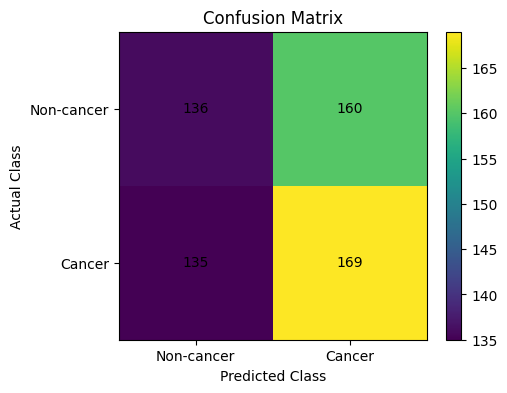

In [ ]:
#STEP 11 — Confusion Matrix Visualization
plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Non-cancer", "Cancer"]
)

plt.yticks(
    [0, 1],
    ["Non-cancer", "Cancer"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

Conclusion:

This practical demonstrates the use of a Machine Learning workflow for classifying clinical observations into cancer and non-cancer groups. The analysis begins with loading and preprocessing the clinical dataset, followed by separating the input features and target variable. The data is divided into training and testing sets, and important clinical features are selected using Mutual Information. A Random Forest Classifier is then trained using the selected features and used to predict the cancer status of the test observations. Finally, the model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score. This workflow demonstrates how Machine Learning can be applied to clinical data for disease classification.